# FitFlow Interface Analysis
This notebook analyzes how different interface designs impact the time it takes users to find and start a workout. We will compare four designs:
* **A:** Traditional Dropdown
* **B:** Visual Grid
* **C:** Search Bar
* **D:** Personalized Feed

In [1]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## 1. Load the Data
First, we load the completion times (in seconds) recorded for users testing each of the four interface designs.

In [2]:
# FitFlow completion times (seconds)
design_A = np.array([45, 42, 47, 44, 46, 43, 48, 45, 44, 46])
design_B = np.array([32, 30, 33, 31, 34, 32, 31, 33, 30, 32])
design_C = np.array([38, 36, 39, 37, 40, 38, 37, 39, 36, 38])
design_D = np.array([35, 33, 36, 34, 37, 35, 34, 36, 33, 35])

## 2. Visualize the Distributions
Before running statistical tests, let's visualize the data using a boxplot to see the spread and median times for each group.

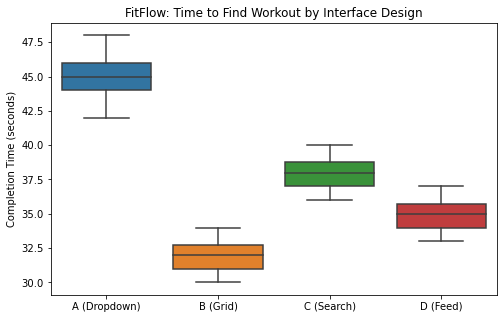

In [3]:
# Combine data for plotting
data = [design_A, design_B, design_C, design_D]
labels = ['A (Dropdown)', 'B (Grid)', 'C (Search)', 'D (Feed)']

# Create a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=data)
plt.xticks(ticks=[0, 1, 2, 3], labels=labels)
plt.ylabel('Completion Time (seconds)')
plt.title('FitFlow: Time to Find Workout by Interface Design')
plt.show()

## 3. One-Way ANOVA
We use a One-Way ANOVA to test if there is a statistically significant difference in mean completion times across *any* of the designs.

In [4]:
# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(design_A, design_B, design_C, design_D)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")

F-statistic: 150.0469
p-value: 2.1131e-20


## 4. Post-Hoc Analysis (Tukey's HSD)
Since the ANOVA tells us *at least one* group is different, we use Tukey's HSD test to compare every design against every other design to see exactly where the differences lie.

In [5]:
# Combine all data into a single array
all_times = np.concatenate([design_A, design_B, design_C, design_D])

# Create matching group labels for each data point
group_labels = ['Traditional']*10 + ['Grid']*10 + ['Search']*10 + ['Personalized']*10

# Run Tukey's HSD test
tukey_results = pairwise_tukeyhsd(endog=all_times, groups=group_labels, alpha=0.05)

# Display the results
print(tukey_results)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1       group2    meandiff p-adj  lower   upper  reject
---------------------------------------------------------------
        Grid Personalized      3.0 0.001  1.2408  4.7592   True
        Grid       Search      6.0 0.001  4.2408  7.7592   True
        Grid  Traditional     13.2 0.001 11.4408 14.9592   True
Personalized       Search      3.0 0.001  1.2408  4.7592   True
Personalized  Traditional     10.2 0.001  8.4408 11.9592   True
      Search  Traditional      7.2 0.001  5.4408  8.9592   True
---------------------------------------------------------------


## 5. Effect Size (Eta-Squared)
Finally, we calculate Eta-squared to determine the magnitude of the effect. This tells us what percentage of the variation in completion times is directly explained by the UI design choice.

In [6]:
# Calculate effect size (Eta-squared)
def calculate_eta_squared(groups):
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    ssb = sum(len(group) * (np.mean(group) - grand_mean)**2 for group in groups)
    sst = sum((x - grand_mean)**2 for x in all_data)
    return ssb / sst

groups = [design_A, design_B, design_C, design_D]
eta_squared = calculate_eta_squared(groups)

print("Effect Size Analysis:")
print(f"Eta-squared: {eta_squared:.3f}")
print(f"Interface design explains {eta_squared*100:.1f}% of variation in start times.")

Effect Size Analysis:
Eta-squared: 0.926
Interface design explains 92.6% of variation in start times.


## 6. Conclusion and Recommendations

**Summary of Findings**
* **Clear Winner:** Design B (Visual Grid) was the most efficient interface, allowing users to find and start a workout in an average of ~32 seconds. 
* **The Slowest Option:** Design A (Traditional Dropdown) caused the most friction, taking users significantly longer (~45 seconds) to complete the same task.
* **Statistical & Practical Significance:** The One-Way ANOVA and post-hoc Tukey HSD test confirm that the differences in completion times between these designs are statistically significant, not just random chance. Furthermore, the high Eta-squared value shows that the interface design is a massive driver of user speed.

**Business Recommendation**
To reduce friction and get users exercising faster, **FitFlow should implement Design B (Visual Grid) as the default interface.** 

Design D (Personalized Feed) also performed well and could be considered for a secondary, personalized home screen, while Design A (Dropdown) should be entirely phased out as it creates an unnecessary bottleneck for the user experience.